# Visualisasi Hasil Scenario I — Confusion Matrix & ROC Curve

Menghasilkan:
- **Confusion Matrix** (DS1 & DS2, 4 model, 2x4 grid)
- **ROC Curve** (DS1 & DS2, 4 model, 2x4 grid)

Semua dari file `.npy` hasil pipeline Scenario I yang sudah tersimpan.


## 1. Imports & Konfigurasi

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
)

BASE_DIR = Path(r'D:\Tree-Structured Parzen Estimator\main')

RESULTS = {
    'densenet121' : BASE_DIR / '[1] densenet121'  / 'full_pipeline_results',
    'inception_v3': BASE_DIR / '[2] inceptionv3'  / 'full_pipeline_results',
    'vit_scratch' : BASE_DIR / '[3] vit'          / 'full_pipeline_results',
    'xception'    : BASE_DIR / '[4] xception'     / 'full_pipeline_results',
}

MODEL_LABELS = {
    'densenet121' : 'DenseNet-121',
    'inception_v3': 'InceptionV3',
    'xception'    : 'Xception',
    'vit_scratch' : 'ViT-Pretrained',
}

# Warna konsisten per model
COLORS = {
    'densenet121' : '#1565C0',
    'inception_v3': '#2E7D32',
    'xception'    : '#6A1B9A',
    'vit_scratch' : '#E65100',
}

OUTPUT_DIR = BASE_DIR / '[6] visualization' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_KEYS = ['densenet121', 'inception_v3', 'xception', 'vit_scratch']

print('Konfigurasi loaded.')
print(f'Output -> {OUTPUT_DIR}')


Konfigurasi loaded.
Output -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output


## 2. Load Probability Arrays

In [2]:
data = {}

for arch in MODEL_KEYS:
    d = RESULTS[arch]
    entry = {}
    for split, fname_p, fname_l in [
        ('ds1', f'probs_ds1_{arch}.npy', 'ds1_labels.npy'),
        ('ds2', f'probs_ds2_{arch}.npy', 'ds2_labels.npy'),
    ]:
        try:
            p = np.load(d / fname_p)
            l = np.load(d / fname_l)
            if p.ndim == 2: p = p[:, 1]
            entry[f'probs_{split}'] = p
            entry[f'labels_{split}'] = l
        except FileNotFoundError as e:
            print(f'  MISSING: {e}')
    data[arch] = entry

print('Semua probabilitas berhasil dimuat.')
for arch in MODEL_KEYS:
    d1 = data[arch].get('probs_ds1')
    d2 = data[arch].get('probs_ds2')
    print(f'  {MODEL_LABELS[arch]:<16}  DS1={d1.shape if d1 is not None else "MISSING"}  DS2={d2.shape if d2 is not None else "MISSING"}')


Semua probabilitas berhasil dimuat.
  DenseNet-121      DS1=(2000,)  DS2=(1000,)
  InceptionV3       DS1=(2000,)  DS2=(1000,)
  Xception          DS1=(2000,)  DS2=(1000,)
  ViT-Pretrained    DS1=(2000,)  DS2=(1000,)


## 3. Confusion Matrix — DS1 & DS2

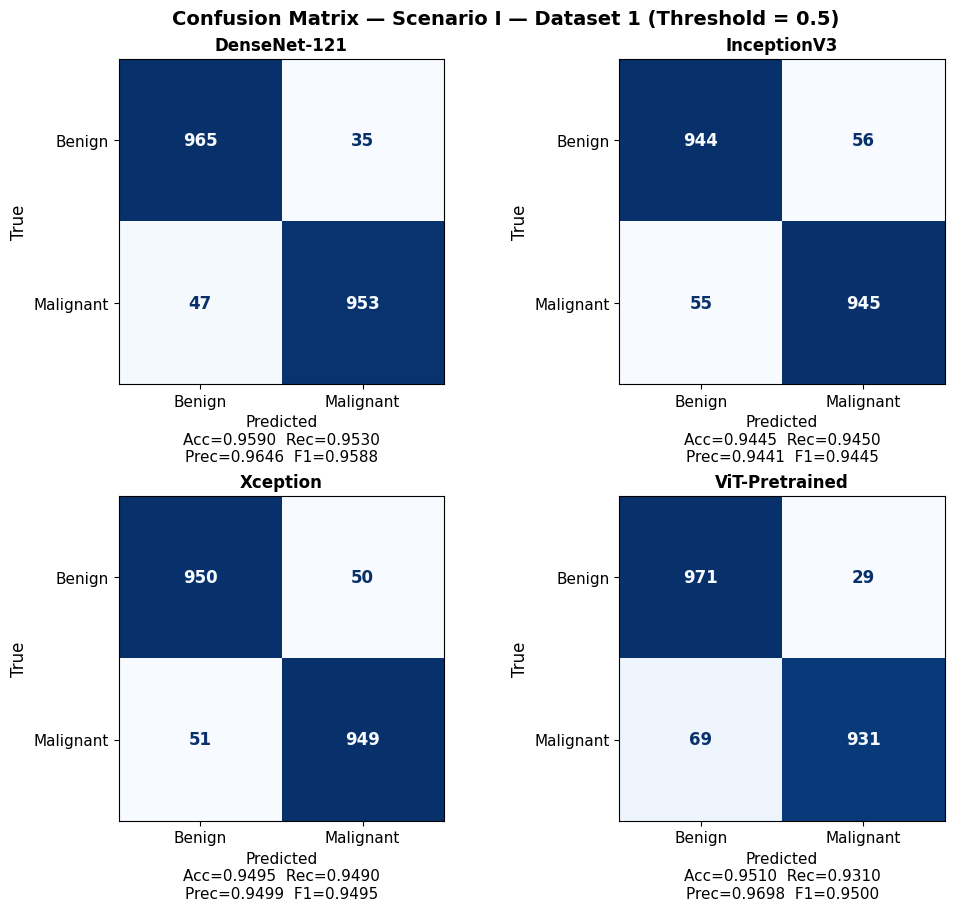

Saved -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output\confusion_matrix_ds1.png


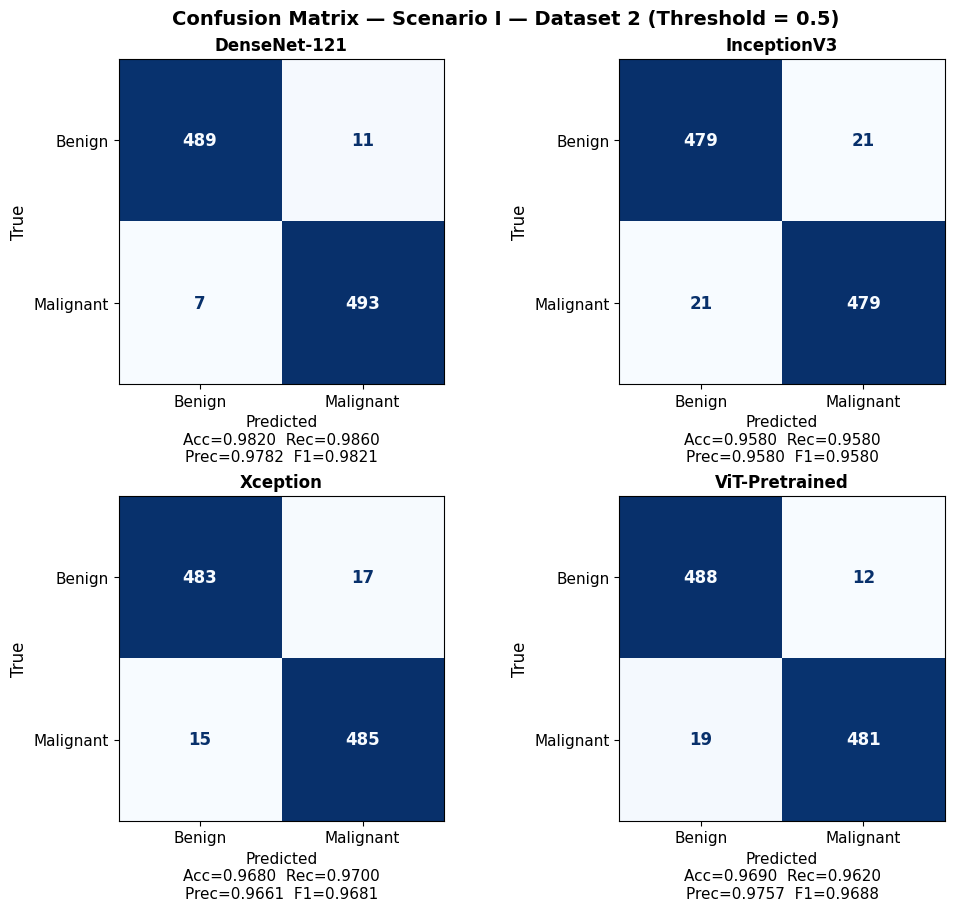

Saved -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output\confusion_matrix_ds2.png


In [9]:
FONT = 12

for split, ds_label, fname in [
    ('ds1', 'Dataset 1',      'confusion_matrix_ds1.png'),
    ('ds2', 'Dataset 2',  'confusion_matrix_ds2.png'),
]:
    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 9),
        constrained_layout=True
    )

    # Background figure transparan
    fig.patch.set_alpha(0)

    fig.suptitle(
        f'Confusion Matrix — Scenario I — {ds_label} (Threshold = 0.5)',
        fontsize=FONT + 2,
        fontweight='bold'
    )

    for ax, arch in zip(axes.flatten(), MODEL_KEYS):
        label  = MODEL_LABELS[arch]
        probs  = data[arch][f'probs_{split}']
        labels = data[arch][f'labels_{split}']
        preds  = (probs >= 0.5).astype(int)

        cm = confusion_matrix(labels, preds)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Benign', 'Malignant']
        )

        disp.plot(
            ax=ax,
            cmap='Blues',
            colorbar=False,
            values_format='d'
        )

        # Background subplot transparan
        ax.set_facecolor('none')

        tn, fp, fn, tp = cm.ravel()

        acc  = (tp + tn) / len(labels)
        rec  = tp / (tp + fn + 1e-12)
        prec = tp / (tp + fp + 1e-12)
        f1   = 2 * prec * rec / (prec + rec + 1e-12)

        ax.set_title(
            label,
            fontsize=FONT,
            fontweight='bold'
        )

        ax.set_xlabel(
            f'Predicted\n'
            f'Acc={acc:.4f}  Rec={rec:.4f}\n'
            f'Prec={prec:.4f}  F1={f1:.4f}',
            fontsize=FONT - 1
        )

        ax.set_ylabel(
            'True',
            fontsize=FONT
        )

        ax.tick_params(
            axis='both',
            labelsize=FONT - 1
        )

        # Perbesar angka pada confusion matrix
        for text in ax.texts:
            text.set_fontsize(FONT)
            text.set_fontweight('bold')

    out_path = OUTPUT_DIR / fname

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches='tight',
        transparent=True,
        facecolor='white',
        edgecolor='none'
    )

    plt.show()

    print(f'Saved -> {out_path}')

## 4. ROC Curve — DS1 & DS2

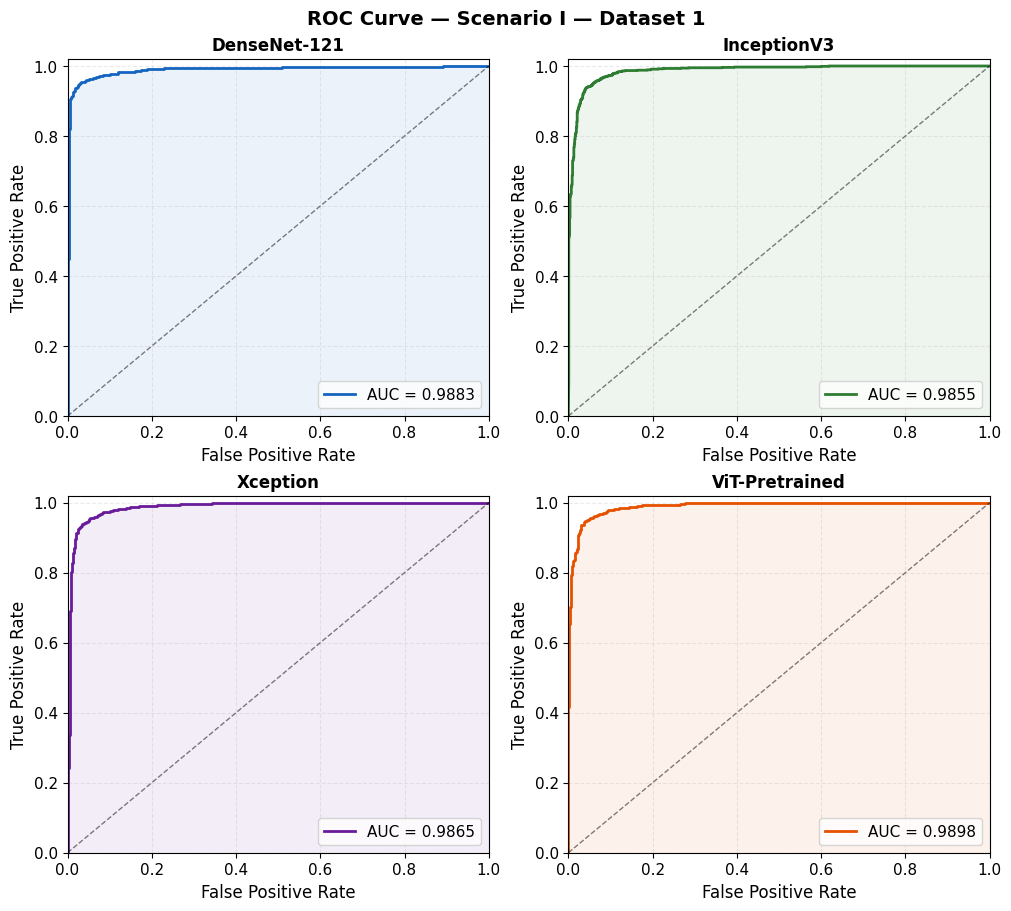

Saved -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output\roc_curve_ds1.png


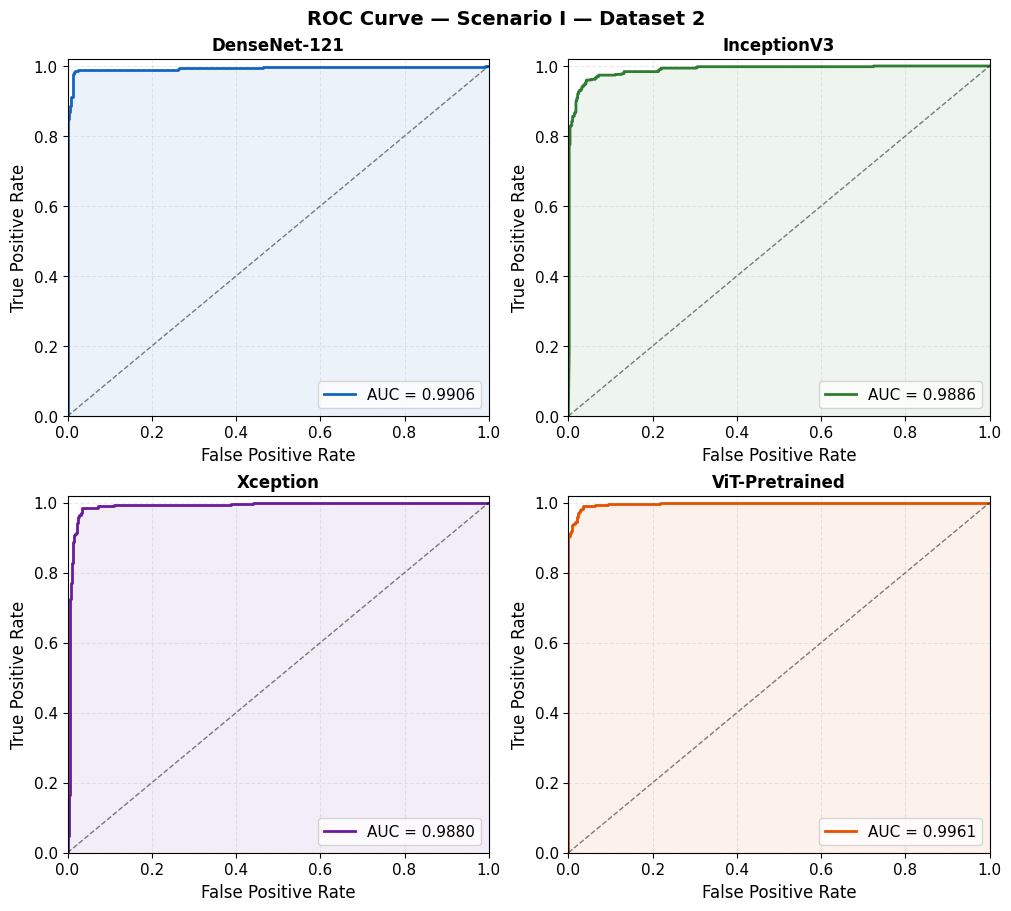

Saved -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output\roc_curve_ds2.png


In [10]:
FONT = 12

for split, ds_label, fname in [
    ('ds1', 'Dataset 1',      'roc_curve_ds1.png'),
    ('ds2', 'Dataset 2',  'roc_curve_ds2.png'),
]:
    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 9),
        constrained_layout=True
    )

    # Background figure transparan
    fig.patch.set_alpha(0)

    fig.suptitle(
        f'ROC Curve — Scenario I — {ds_label}',
        fontsize=FONT + 2,
        fontweight='bold'
    )

    for ax, arch in zip(axes.flatten(), MODEL_KEYS):
        label  = MODEL_LABELS[arch]
        color  = COLORS[arch]
        probs  = data[arch][f'probs_{split}']
        labels = data[arch][f'labels_{split}']

        fpr, tpr, _ = roc_curve(labels, probs)
        auc = roc_auc_score(labels, probs)

        ax.plot(
            fpr, tpr,
            color=color,
            lw=2,
            label=f'AUC = {auc:.4f}'
        )

        ax.plot(
            [0, 1], [0, 1],
            'k--',
            lw=1,
            alpha=0.5
        )

        ax.fill_between(
            fpr, tpr,
            alpha=0.08,
            color=color
        )

        ax.set_title(
            label,
            fontsize=FONT,
            fontweight='bold'
        )

        ax.set_xlabel(
            'False Positive Rate',
            fontsize=FONT
        )

        ax.set_ylabel(
            'True Positive Rate',
            fontsize=FONT
        )

        ax.legend(
            loc='lower right',
            fontsize=FONT - 1,
            frameon=True
        )

        ax.tick_params(
            axis='both',
            labelsize=FONT - 1
        )

        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])

        ax.grid(
            alpha=0.25,
            linestyle='--'
        )

        # Background subplot transparan
        ax.set_facecolor('none')

    out_path = OUTPUT_DIR / fname

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches='tight',
        transparent=True,
        facecolor='white',
        edgecolor='none'
    )

    plt.show()

    print(f'Saved -> {out_path}')

## 5. Ringkasan Metrik (Tabel)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rows = []
for arch in MODEL_KEYS:
    label = MODEL_LABELS[arch]
    for split in ['ds1', 'ds2']:
        probs  = data[arch][f'probs_{split}']
        labels = data[arch][f'labels_{split}']
        preds  = (probs >= 0.5).astype(int)
        try:
            auc = roc_auc_score(labels, probs)
        except:
            auc = 0.0
        rows.append({
            'Model'    : label,
            'Dataset'  : split.upper(),
            'Accuracy' : round(accuracy_score(labels, preds), 4),
            'Precision': round(precision_score(labels, preds, zero_division=0), 4), # type: ignore
            'Recall'   : round(recall_score(labels, preds, zero_division=0), 4), # type: ignore
            'F1'       : round(f1_score(labels, preds, zero_division=0), 4), # type: ignore
            'AUC'      : round(auc, 4),
        })

import pandas as pd
df = pd.DataFrame(rows)
print(df.to_string(index=False))

df.to_csv(OUTPUT_DIR / 'metrics_scenario1_all.csv', index=False)
print(f'\nSaved -> {OUTPUT_DIR / "metrics_scenario1_all.csv"}')


         Model Dataset  Accuracy  Precision  Recall     F1    AUC
  DenseNet-121     DS1    0.9590     0.9646   0.953 0.9588 0.9883
  DenseNet-121     DS2    0.9820     0.9782   0.986 0.9821 0.9906
   InceptionV3     DS1    0.9445     0.9441   0.945 0.9445 0.9855
   InceptionV3     DS2    0.9580     0.9580   0.958 0.9580 0.9886
      Xception     DS1    0.9495     0.9499   0.949 0.9495 0.9865
      Xception     DS2    0.9680     0.9661   0.970 0.9681 0.9880
ViT-Pretrained     DS1    0.9510     0.9698   0.931 0.9500 0.9898
ViT-Pretrained     DS2    0.9690     0.9757   0.962 0.9688 0.9961

Saved -> D:\Tree-Structured Parzen Estimator\main\[6] visualization\output\metrics_scenario1_all.csv


## 6. Perbandingan dengan Penelitian Sebelumnya

Tabel berikut menyajikan perbandingan hasil model yang diusulkan (*proposed model*) dengan studi-studi referensi yang ada.


In [1]:
import pandas as pd
from IPython.display import display

# ─────────────────────────────────────────────────────────────
# DATASET 1 comparison table
# ─────────────────────────────────────────────────────────────
ds1_data = [
    {'Source': 'Sarıateş & Özbay', 'Model': 'DenseNet121',             'Accuracy': '94.50%', 'Precision': '93.90%', 'Recall': '95.04%', 'F1-Score': '94.47%'},
    {'Source': 'Sarıateş & Özbay', 'Model': 'InceptionV3',             'Accuracy': '91.20%', 'Precision': '93.20%', 'Recall': '89.62%', 'F1-Score': '91.37%'},
    {'Source': 'Sarıateş & Özbay', 'Model': 'ViT',                     'Accuracy': '88.25%', 'Precision': '90.50%', 'Recall': '86.60%', 'F1-Score': '88.50%'},
    {'Source': 'Sarıateş & Özbay', 'Model': 'Xception',                'Accuracy': '93.80%', 'Precision': '93.00%', 'Recall': '94.51%', 'F1-Score': '93.75%'},
    {'Source': 'Sarıateş & Özbay', 'Model': 'Ensemble Learning',       'Accuracy': '95.25%', 'Precision': '94.20%', 'Recall': '96.22%', 'F1-Score': '95.20%'},
    {'Source': 'Mahmud et al.',     'Model': 'Xception (custom dense)', 'Accuracy': '91.09%', 'Precision': '94.72%', 'Recall': '91.79%', 'F1-Score': '91.95%'},
    {'Source': 'Proposed Model',    'Model': 'DenseNet-121',            'Accuracy': '95.90%', 'Precision': '96.46%', 'Recall': '95.30%', 'F1-Score': '95.88%'},
    {'Source': 'Proposed Model',    'Model': 'InceptionV3',             'Accuracy': '94.45%', 'Precision': '94.41%', 'Recall': '94.50%', 'F1-Score': '94.45%'},
    {'Source': 'Proposed Model',    'Model': 'Xception',                'Accuracy': '94.95%', 'Precision': '94.99%', 'Recall': '94.90%', 'F1-Score': '94.95%'},
    {'Source': 'Proposed Model',    'Model': 'ViT-Pretrained',          'Accuracy': '95.10%', 'Precision': '96.98%', 'Recall': '93.10%', 'F1-Score': '95.00%'},
    {'Source': 'Proposed Model',    'Model': 'Ensemble',                'Accuracy': '96.25%', 'Precision': '97.15%', 'Recall': '95.30%', 'F1-Score': '96.21%'},
]

df_ds1 = pd.DataFrame(ds1_data)

# ─────────────────────────────────────────────────────────────
# DATASET 2 comparison table
# ─────────────────────────────────────────────────────────────
ds2_data = [
    {'Source': 'Mahmud et al.',     'Model': 'Xception (custom dense)', 'Accuracy': '89.29%', 'Precision': '89.61%', 'Recall': '89.17%', 'F1-Score': '89.39%'},
    {'Source': 'Sabir & Mehmood',   'Model': 'Basic CNN',               'Accuracy': '80.00%', 'Precision': '93.00%', 'Recall': '64.00%', 'F1-Score': '76.00%'},
    {'Source': 'Sabir & Mehmood',   'Model': 'ResNet-18',               'Accuracy': '87.00%', 'Precision': '91.00%', 'Recall': '82.00%', 'F1-Score': '86.00%'},
    {'Source': 'Sabir & Mehmood',   'Model': 'EfficientNet-B0',         'Accuracy': '97.00%', 'Precision': '95.00%', 'Recall': '99.00%', 'F1-Score': '97.00%'},
    {'Source': 'Proposed Model',    'Model': 'DenseNet-121',            'Accuracy': '98.20%', 'Precision': '97.82%', 'Recall': '98.60%', 'F1-Score': '98.21%'},
    {'Source': 'Proposed Model',    'Model': 'InceptionV3',             'Accuracy': '95.80%', 'Precision': '95.80%', 'Recall': '95.80%', 'F1-Score': '95.80%'},
    {'Source': 'Proposed Model',    'Model': 'Xception',                'Accuracy': '96.80%', 'Precision': '96.61%', 'Recall': '97.00%', 'F1-Score': '96.81%'},
    {'Source': 'Proposed Model',    'Model': 'ViT-Pretrained',          'Accuracy': '96.90%', 'Precision': '97.57%', 'Recall': '96.20%', 'F1-Score': '96.88%'},
    {'Source': 'Proposed Model',    'Model': 'Ensemble',                'Accuracy': '97.80%', 'Precision': '97.99%', 'Recall': '97.60%', 'F1-Score': '97.80%'},
]

df_ds2 = pd.DataFrame(ds2_data)

# ─────────────────────────────────────────────────────────────
# Display
# ─────────────────────────────────────────────────────────────
print('Dataset 1 – Melanoma Cancer Image Dataset')
display(df_ds1.style.hide(axis='index'))

print('\nDataset 2 – CNN for Melanoma Detection')
display(df_ds2.style.hide(axis='index'))

Dataset 1 – Melanoma Cancer Image Dataset


Source,Model,Accuracy,Precision,Recall,F1-Score
Sarıateş & Özbay,DenseNet121,94.50%,93.90%,95.04%,94.47%
Sarıateş & Özbay,InceptionV3,91.20%,93.20%,89.62%,91.37%
Sarıateş & Özbay,ViT,88.25%,90.50%,86.60%,88.50%
Sarıateş & Özbay,Xception,93.80%,93.00%,94.51%,93.75%
Sarıateş & Özbay,Ensemble Learning,95.25%,94.20%,96.22%,95.20%
Mahmud et al.,Xception (custom dense),91.09%,94.72%,91.79%,91.95%
Proposed Model,DenseNet-121,95.90%,96.46%,95.30%,95.88%
Proposed Model,InceptionV3,94.45%,94.41%,94.50%,94.45%
Proposed Model,Xception,94.95%,94.99%,94.90%,94.95%
Proposed Model,ViT-Pretrained,95.10%,96.98%,93.10%,95.00%



Dataset 2 – CNN for Melanoma Detection


Source,Model,Accuracy,Precision,Recall,F1-Score
Mahmud et al.,Xception (custom dense),89.29%,89.61%,89.17%,89.39%
Sabir & Mehmood,Basic CNN,80.00%,93.00%,64.00%,76.00%
Sabir & Mehmood,ResNet-18,87.00%,91.00%,82.00%,86.00%
Sabir & Mehmood,EfficientNet-B0,97.00%,95.00%,99.00%,97.00%
Proposed Model,DenseNet-121,98.20%,97.82%,98.60%,98.21%
Proposed Model,InceptionV3,95.80%,95.80%,95.80%,95.80%
Proposed Model,Xception,96.80%,96.61%,97.00%,96.81%
Proposed Model,ViT-Pretrained,96.90%,97.57%,96.20%,96.88%
Proposed Model,Ensemble,97.80%,97.99%,97.60%,97.80%
